# Exploratory Data Analysis (EDA)
## Online Shoppers Purchasing Intention Dataset

**Goal**: Understand the data before building any models.

### What we'll do:
1. Load and inspect the data
2. Check for missing values
3. Understand column types
4. Identify the target variable
5. Check for class imbalance
6. Visualize key distributions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our custom module
import sys
sys.path.append('..')
from src.data_loader import load_data, get_basic_info, identify_column_types

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load the Data

In [2]:
# Load dataset
df = load_data('../data/online_shoppers_intention.csv')

# First look at the data
df.head()

Dataset loaded: 12330 rows, 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2. Basic Dataset Information

In [3]:
# Shape of the dataset
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\n" + "="*50)
print("\nColumn data types:")
print(df.dtypes)

Dataset shape: 12330 rows x 18 columns


Column data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


In [4]:
# Detailed info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

## 3. Missing Values Analysis

**Why this matters**: Missing values can cause errors or bias in ML models. We need to know:
- Are there any missing values?
- Which columns have them?
- How much is missing?

In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Only show columns with missing values (if any)
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %


In [6]:
print(f"Total missing values in dataset: {df.isnull().sum().sum()}")

Total missing values in dataset: 0


## 4. Understanding Column Types

For ML, we need to know:
- **Numerical**: Can be used directly (may need scaling for neural networks)
- **Categorical**: Need encoding (one-hot or label encoding)
- **Boolean**: Special categorical (True/False)

In [7]:
col_types = identify_column_types(df)

print("NUMERICAL COLUMNS:")
print("-" * 40)
for col in col_types['numerical']:
    print(f"  {col}")
print(f"\nTotal: {len(col_types['numerical'])} columns")

NUMERICAL COLUMNS:
----------------------------------------
  Administrative
  Administrative_Duration
  Informational
  Informational_Duration
  ProductRelated
  ProductRelated_Duration
  BounceRates
  ExitRates
  PageValues
  SpecialDay
  OperatingSystems
  Browser
  Region
  TrafficType

Total: 14 columns


In [8]:
print("CATEGORICAL COLUMNS:")
print("-" * 40)
for col in col_types['categorical']:
    unique_vals = df[col].unique()
    print(f"  {col}: {len(unique_vals)} unique values")
    if len(unique_vals) <= 12:  # Show values if not too many
        print(f"      Values: {sorted(unique_vals)}")

CATEGORICAL COLUMNS:
----------------------------------------
  Month: 10 unique values
      Values: ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']
  VisitorType: 3 unique values
      Values: ['New_Visitor', 'Other', 'Returning_Visitor']


In [9]:
print("BOOLEAN COLUMNS:")
print("-" * 40)
for col in col_types['boolean']:
    print(f"  {col}: {df[col].unique()}")
print(f"\nTotal: {len(col_types['boolean'])} columns")

BOOLEAN COLUMNS:
----------------------------------------
  Weekend: [False  True]
  Revenue: [False  True]

Total: 2 columns


## 5. Identify the Target Variable

The target variable is **`Revenue`** - it indicates whether the shopping session ended with a purchase (True) or not (False).

This is a **binary classification** problem.

In [10]:
target = 'Revenue'

print(f"Target variable: {target}")
print(f"Data type: {df[target].dtype}")
print(f"\nValue counts:")
print(df[target].value_counts())

Target variable: Revenue
Data type: bool

Value counts:
Revenue
False    10422
True      1908
Name: count, dtype: int64


## 6. Check for Class Imbalance

**Why this matters**: If one class is much more common than the other, the model might just predict the majority class and still get high accuracy.

**Rule of thumb**: If the minority class is less than 20-30% of the data, consider:
- Using metrics like F1-score, precision, recall (not just accuracy)
- Stratified train/test splits
- Class weights or resampling techniques

In [11]:
# Class distribution
class_counts = df[target].value_counts()
class_pct = df[target].value_counts(normalize=True) * 100

print("CLASS DISTRIBUTION:")
print("=" * 40)
print(f"No Purchase (False): {class_counts[False]:,} ({class_pct[False]:.1f}%)")
print(f"Purchase (True):     {class_counts[True]:,} ({class_pct[True]:.1f}%)")
print("=" * 40)

# Calculate imbalance ratio
imbalance_ratio = class_counts[False] / class_counts[True]
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")

CLASS DISTRIBUTION:
No Purchase (False): 10,422 (84.5%)
Purchase (True):     1,908 (15.5%)

Imbalance ratio: 5.46:1


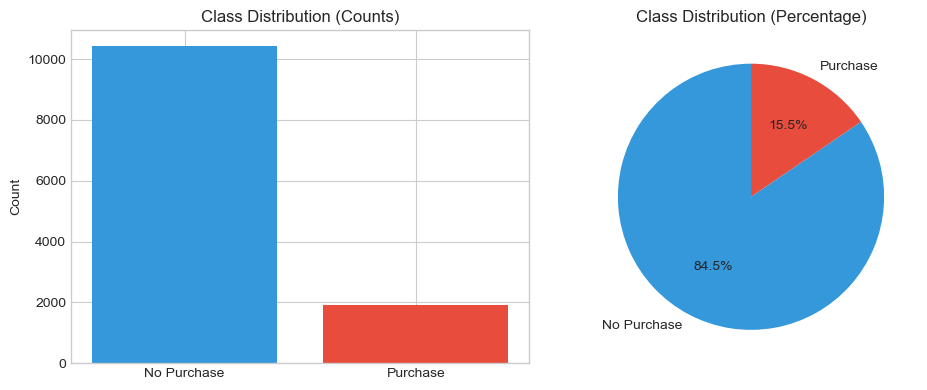


⚠️  OBSERVATION: This dataset has class imbalance (~84% No Purchase vs ~16% Purchase)
   We should use stratified splitting and focus on F1-score, not just accuracy.


In [12]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar plot
colors = ['#3498db', '#e74c3c']
axes[0].bar(['No Purchase', 'Purchase'], class_counts.values, color=colors)
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Counts)')

# Pie chart
axes[1].pie(class_counts.values, labels=['No Purchase', 'Purchase'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n⚠️  OBSERVATION: This dataset has class imbalance (~84% No Purchase vs ~16% Purchase)")
print("   We should use stratified splitting and focus on F1-score, not just accuracy.")

## 7. Numerical Features - Summary Statistics

In [13]:
# Summary statistics for numerical columns
df[col_types['numerical']].describe().round(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00


## 8. Feature Distribution Visualizations

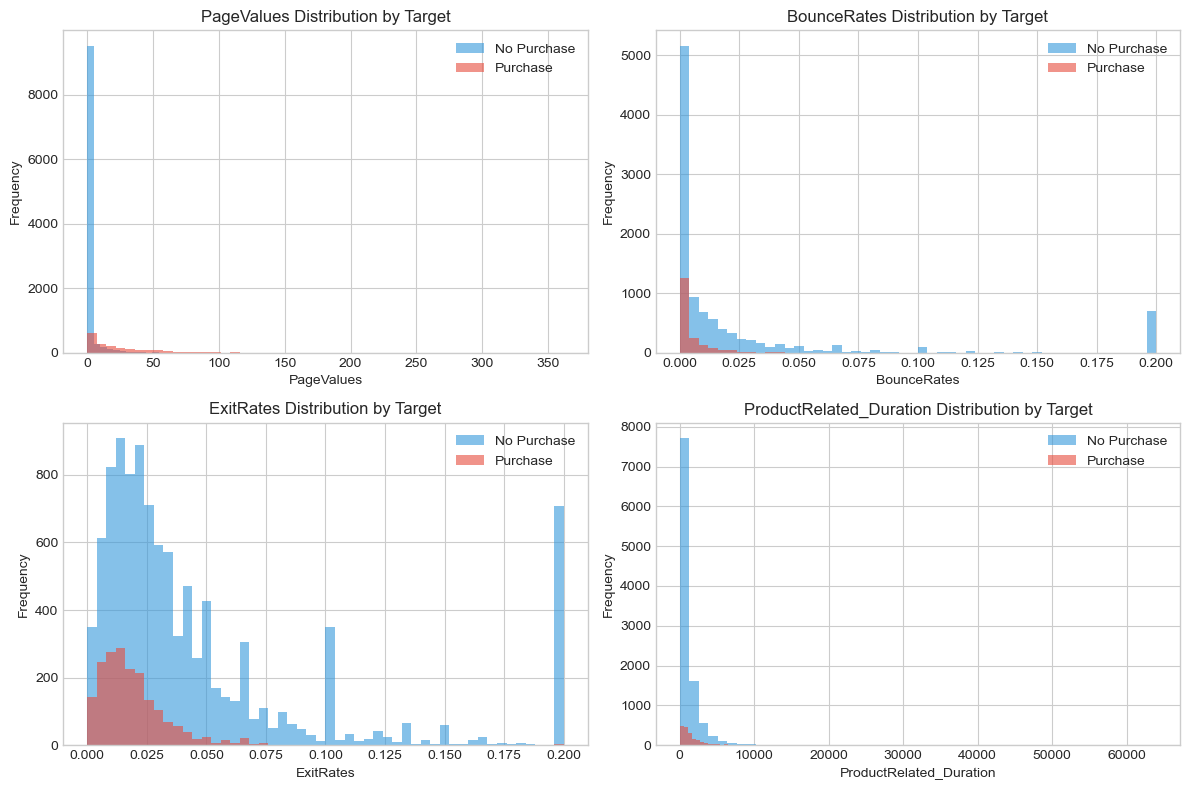

In [14]:
# Select a few key numerical features to visualize
key_features = ['PageValues', 'BounceRates', 'ExitRates', 'ProductRelated_Duration']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    # Split by target
    no_purchase = df[df[target] == False][col]
    purchase = df[df[target] == True][col]
    
    axes[i].hist(no_purchase, bins=50, alpha=0.6, label='No Purchase', color='#3498db')
    axes[i].hist(purchase, bins=50, alpha=0.6, label='Purchase', color='#e74c3c')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].set_title(f'{col} Distribution by Target')

plt.tight_layout()
plt.savefig('../data/feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Categorical Features Analysis

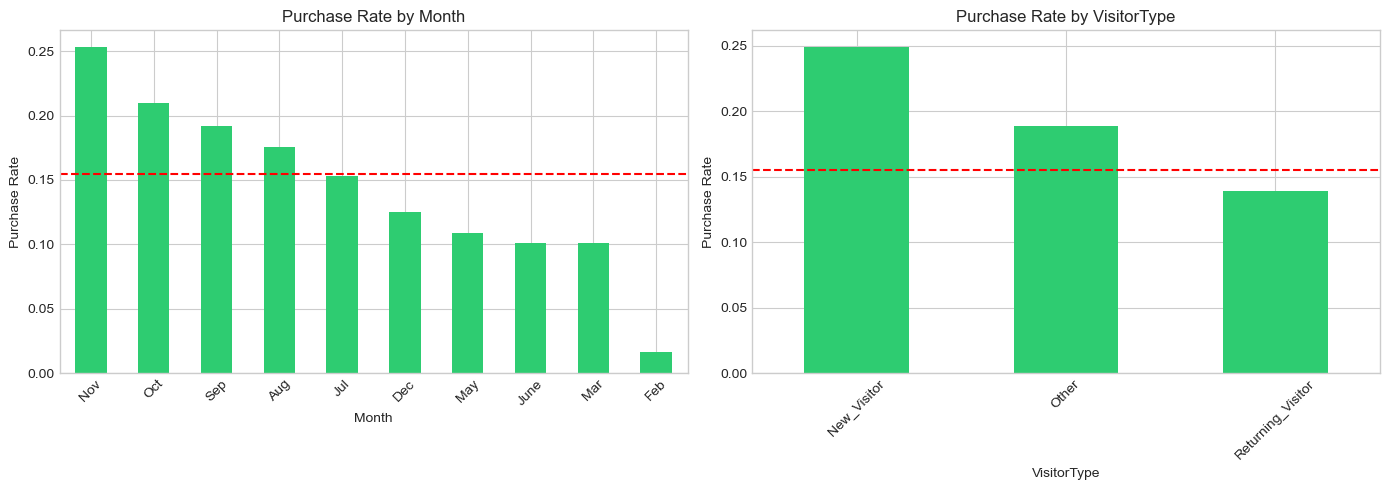

In [15]:
# Analyze categorical features
cat_cols = col_types['categorical']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(14, 5))

for i, col in enumerate(cat_cols):
    # Calculate purchase rate by category
    purchase_rate = df.groupby(col)[target].mean().sort_values(ascending=False)
    
    purchase_rate.plot(kind='bar', ax=axes[i], color='#2ecc71')
    axes[i].set_title(f'Purchase Rate by {col}')
    axes[i].set_ylabel('Purchase Rate')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(y=df[target].mean(), color='red', linestyle='--', label='Overall avg')

plt.tight_layout()
plt.savefig('../data/categorical_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Key Observations Summary

After this EDA, here's what we know:

### Dataset:
- **Rows**: ~12,330 shopping sessions
- **Columns**: 18 features
- **Missing values**: Check output above

### Target Variable:
- **`Revenue`**: Binary (True = purchase, False = no purchase)
- **Class imbalance**: ~84% No Purchase, ~16% Purchase

### Feature Types:
- **Numerical**: Page values, durations, bounce rates, etc.
- **Categorical**: Month, VisitorType, Region, Browser, etc.
- **Boolean**: Weekend, Revenue

### Preprocessing Needed:
1. Encode categorical variables (one-hot for Month, VisitorType, etc.)
2. Convert boolean columns to 0/1
3. Scale numerical features (for neural network only)
4. Use stratified train/test split due to class imbalance

### Next Step:
Build the preprocessing pipeline in `src/preprocessing.py`

In [16]:
print("EDA Complete!")
print("Next: Run preprocessing and model training from main.py")

EDA Complete!
Next: Run preprocessing and model training from main.py
